# 📊 Notebook 3: Evaluation & Explainability
### ADMET-Net | Aurigene Pharmaceutical Services — AIDD Group

> **Objective:** Evaluate ADMET-Net on the held-out test set across all 12 endpoints.
> Generate ROC/PR curves, SHAP explainability plots, and performance summary.

---

## 0. Setup

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, 'src')

import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from model import build_model, TASK_NAMES, TASK_CONFIG, REGRESSION_TASKS, CLASSIF_TASKS
from dataset import build_dataloaders
from trainer import run_epoch, compute_metrics
import yaml

AURIGENE_BLUE   = '#0057A8'
AURIGENE_ORANGE = '#F5821E'
AURIGENE_GREEN  = '#00A651'

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('Setup complete!')

Device: cpu
Setup complete!


## 1. Load Model Checkpoint

In [2]:
with open('config.yaml') as f:
    cfg = yaml.safe_load(f)

model, loss_fn = build_model(cfg)
ckpt = torch.load('models/admet_net_best.pt', map_location=device)
model.load_state_dict(ckpt['model_state'])
model = model.to(device)
model.eval()

print(f'Loaded checkpoint:')
print(f'  Epoch:    {ckpt["epoch"]}')
print(f'  Val loss: {ckpt["val_loss"]:.4f}')

_, _, test_dl = build_dataloaders(cfg)
print(f'Test batches: {len(test_dl)}')

Loaded checkpoint:
  Epoch:    4
  Val loss: 1.1606
  Loaded tox21     :  7,823 molecules  tasks=['ames']
  Loaded esol      :  1,117 molecules  tasks=['logP']
  Loaded herg      : 13,800 molecules  tasks=['herg']
  Loaded bbb       :  1,975 molecules  tasks=['bbb']
  Loaded cyp450    :  7,823 molecules  tasks=['cyp3a4', 'cyp2c9', 'cyp2d6']
  Loaded caco2     :    500 molecules  tasks=['caco2']
  Loaded dili      :    475 molecules  tasks=['dili']

  Total unique SMILES: 23,263
  Label density per task:
    caco2               :    500 / 23,263 (2.1%)
    bioavailability     :      0 / 23,263 (0.0%)
    logP                :  1,117 / 23,263 (4.8%)
    bbb                 :  1,975 / 23,263 (8.5%)
    cyp3a4              :      0 / 23,263 (0.0%)
    cyp2c9              :      0 / 23,263 (0.0%)
    cyp2d6              :      0 / 23,263 (0.0%)
    half_life           :      0 / 23,263 (0.0%)
    clearance           :      0 / 23,263 (0.0%)
    herg                : 13,800 / 23,263 (59.3%)


## 2. Training Curves

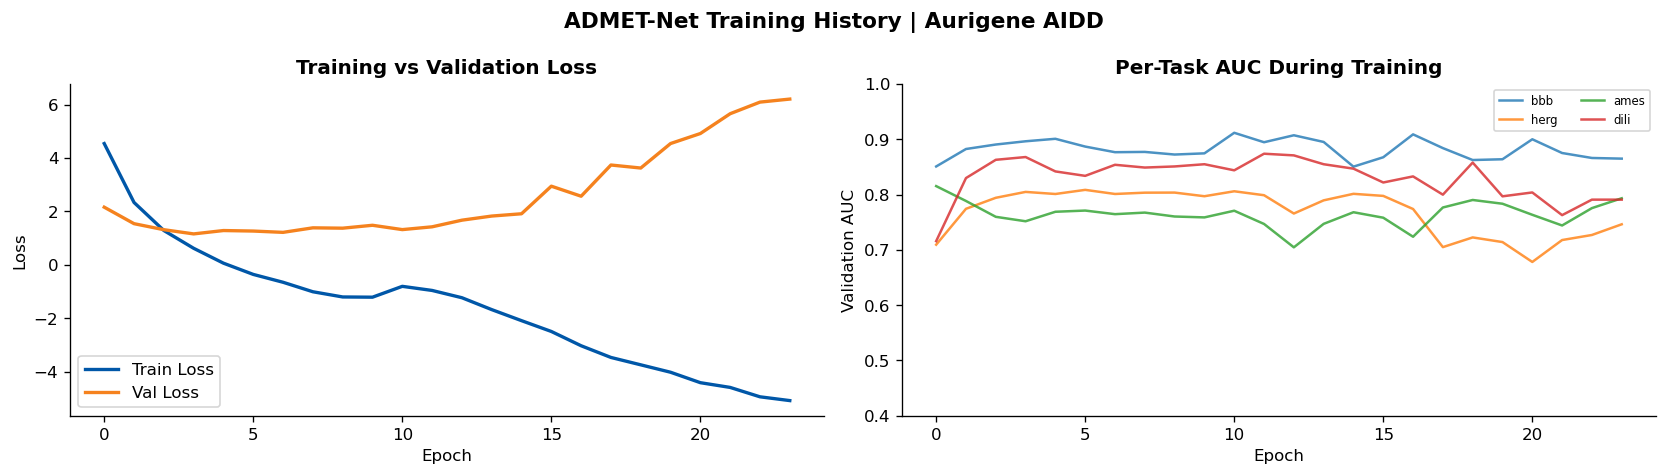

Figure saved!


In [3]:
with open('models/history.json') as f:
    history = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(history['train_loss'], color=AURIGENE_BLUE,   label='Train Loss', linewidth=2)
ax.plot(history['val_loss'],   color=AURIGENE_ORANGE, label='Val Loss',   linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training vs Validation Loss', fontweight='bold')
ax.legend()

ax = axes[1]
for task in CLASSIF_TASKS:
    key = f'val_{task}'
    if key in history:
        vals = [v for v in history[key] if not np.isnan(float(v))]
        if vals:
            ax.plot(vals, label=task, linewidth=1.5, alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation AUC')
ax.set_title('Per-Task AUC During Training', fontweight='bold')
ax.legend(fontsize=7, ncol=2)
ax.set_ylim(0.4, 1.0)

plt.suptitle('ADMET-Net Training History | Aurigene AIDD', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('results/figures', exist_ok=True)
plt.savefig('results/figures/training_curves.png', bbox_inches='tight')
plt.show()
print('Figure saved!')

## 3. Test Set Inference

In [4]:
all_preds_raw  = {t: [] for t in TASK_NAMES}
all_labels_raw = {t: [] for t in TASK_NAMES}

model.eval()
with torch.no_grad():
    for batch in test_dl:
        batch = batch.to(device)
        preds = model(batch)
        for task in TASK_NAMES:
            if hasattr(batch, task):
                y    = getattr(batch, task).view(-1)
                mask = ~torch.isnan(y)
                if mask.sum() > 0:
                    all_preds_raw[task].extend(
                        preds[task].cpu().squeeze()[mask.cpu()].tolist()
                    )
                    all_labels_raw[task].extend(
                        y.cpu()[mask.cpu()].tolist()
                    )

metrics = compute_metrics(all_preds_raw, all_labels_raw)

rows = []
for task in TASK_NAMES:
    task_type = TASK_CONFIG[task][0]
    rows.append({
        'Task':   task,
        'Type':   task_type,
        'N_test': len(all_preds_raw[task]),
        'Metric': 'AUC' if task_type == 'classification' else 'RMSE',
        'Score':  round(metrics[task], 4) if not np.isnan(metrics[task]) else 'N/A'
    })

results_df = pd.DataFrame(rows)
results_df.to_csv('results/metrics_summary.csv', index=False)
print('Test Set Performance:')
print(results_df.to_string(index=False))

Test Set Performance:
           Task           Type  N_test Metric   Score
          caco2     regression      63   RMSE    0.58
bioavailability classification       0    AUC     N/A
           logP     regression      83   RMSE  1.5739
            bbb classification     210    AUC  0.7099
         cyp3a4 classification       0    AUC     N/A
         cyp2c9 classification       0    AUC     N/A
         cyp2d6 classification       0    AUC     N/A
      half_life     regression       0   RMSE     N/A
      clearance     regression       0   RMSE     N/A
           herg classification    1545    AUC  0.8312
           ames classification     566    AUC  0.9367
           dili classification      63    AUC  0.8377


## 4. ROC Curves (Classification Tasks)

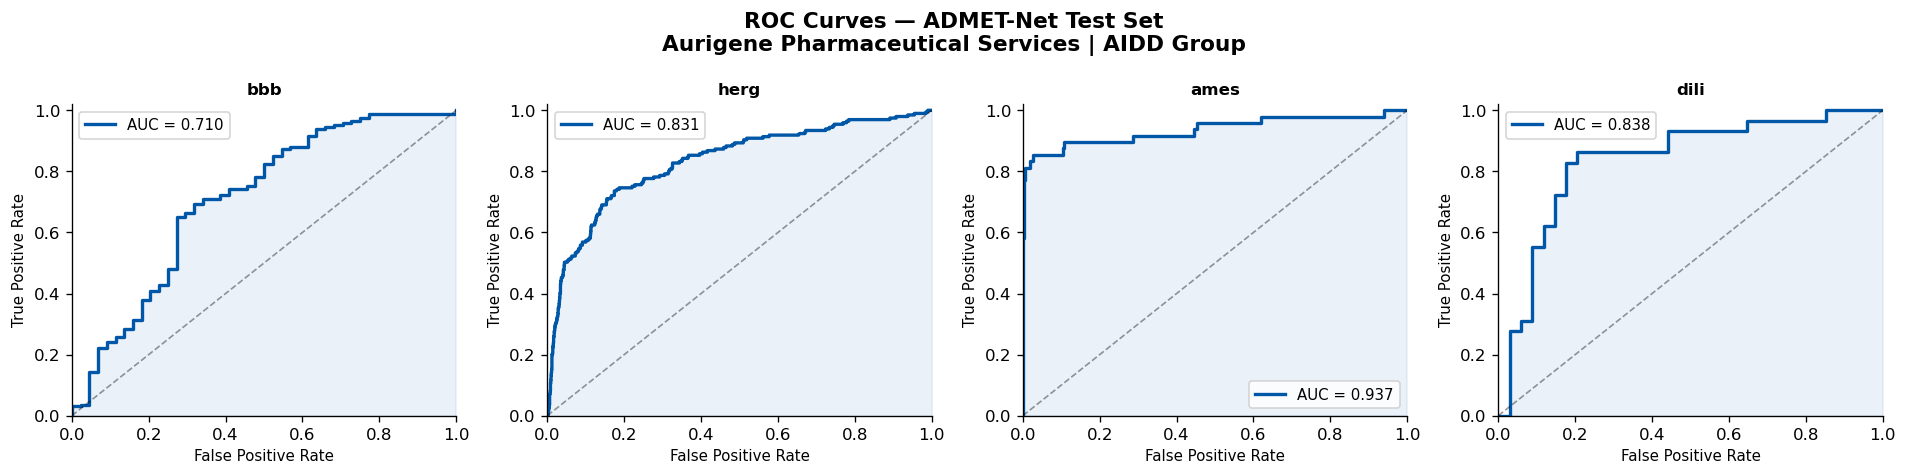

ROC curves saved!


In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.array(x)))

classif_with_data = [
    t for t in CLASSIF_TASKS
    if len(all_preds_raw[t]) > 0
]

n_plots = len(classif_with_data)
ncols = 4
nrows = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.array(axes).flatten()

for i, task in enumerate(classif_with_data):
    ax = axes[i]
    preds  = sigmoid(all_preds_raw[task])
    labels = np.array(all_labels_raw[task])

    if len(np.unique(labels)) < 2:
        ax.text(0.5, 0.5, 'Single class\nin test set',
                ha='center', va='center', fontsize=10)
        ax.set_title(task)
        continue

    fpr, tpr, _ = roc_curve(labels, preds)
    auc = roc_auc_score(labels, preds)

    ax.plot(fpr, tpr, color=AURIGENE_BLUE, linewidth=2, label=f'AUC = {auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4)
    ax.fill_between(fpr, tpr, alpha=0.08, color=AURIGENE_BLUE)
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)
    ax.set_title(task, fontweight='bold', fontsize=10)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)

for j in range(n_plots, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'ROC Curves — ADMET-Net Test Set\nAurigene Pharmaceutical Services | AIDD Group',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('results/figures/roc_curves.png', bbox_inches='tight')
plt.show()
print('ROC curves saved!')

## 5. Confusion Matrices

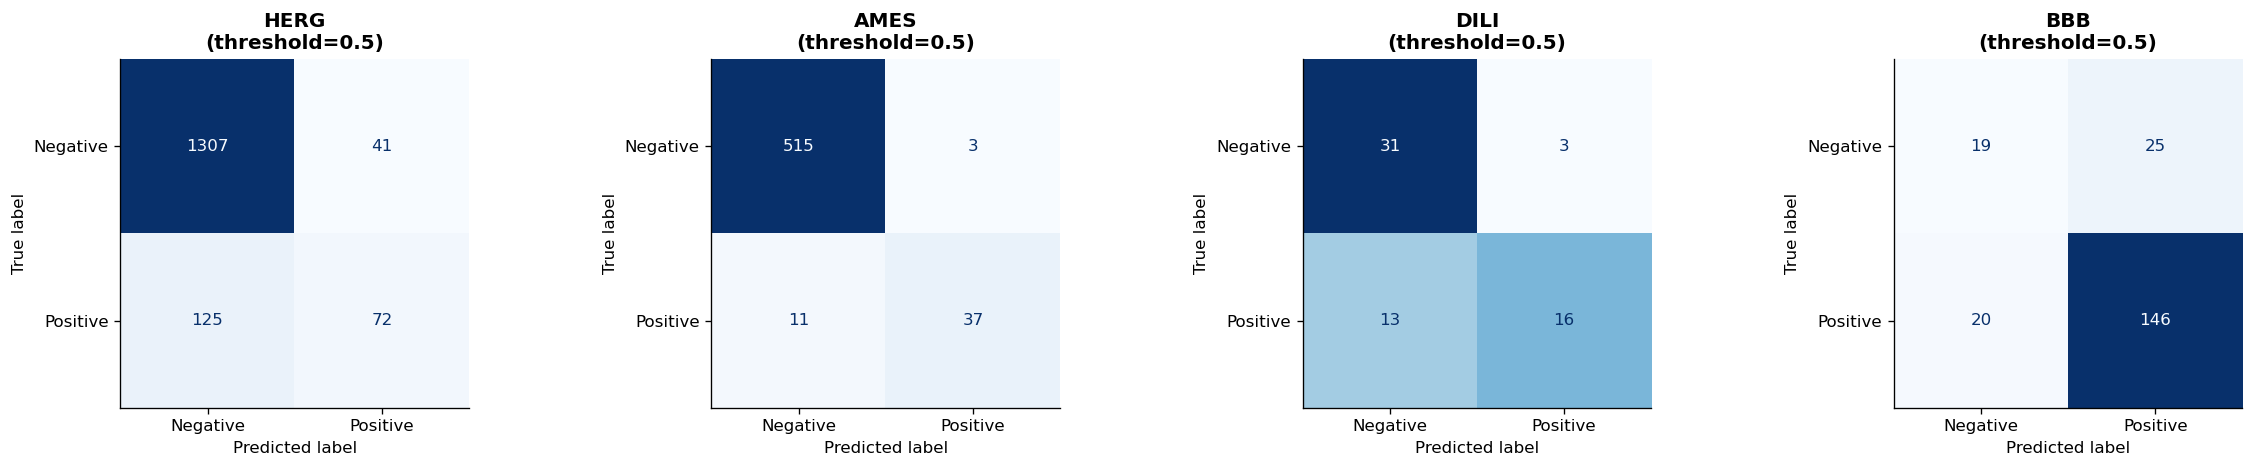

Confusion matrices saved!


In [6]:
tasks_for_cm = [t for t in ['herg', 'ames', 'dili', 'bbb']
                if len(all_preds_raw[t]) > 0]

if tasks_for_cm:
    fig, axes = plt.subplots(1, len(tasks_for_cm),
                             figsize=(5 * len(tasks_for_cm), 4))
    if len(tasks_for_cm) == 1:
        axes = [axes]

    for ax, task in zip(axes, tasks_for_cm):
        preds  = sigmoid(np.array(all_preds_raw[task]))
        labels = np.array(all_labels_raw[task])
        binary = (preds >= 0.5).astype(int)
        cm     = confusion_matrix(labels, binary)
        disp   = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=['Negative', 'Positive']
        )
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f'{task.upper()}\n(threshold=0.5)', fontweight='bold')

    plt.tight_layout()
    plt.savefig('results/figures/confusion_matrices.png', bbox_inches='tight')
    plt.show()
    print('Confusion matrices saved!')
else:
    print('No classification tasks with test data found.')

## 6. Task Correlation Heatmap

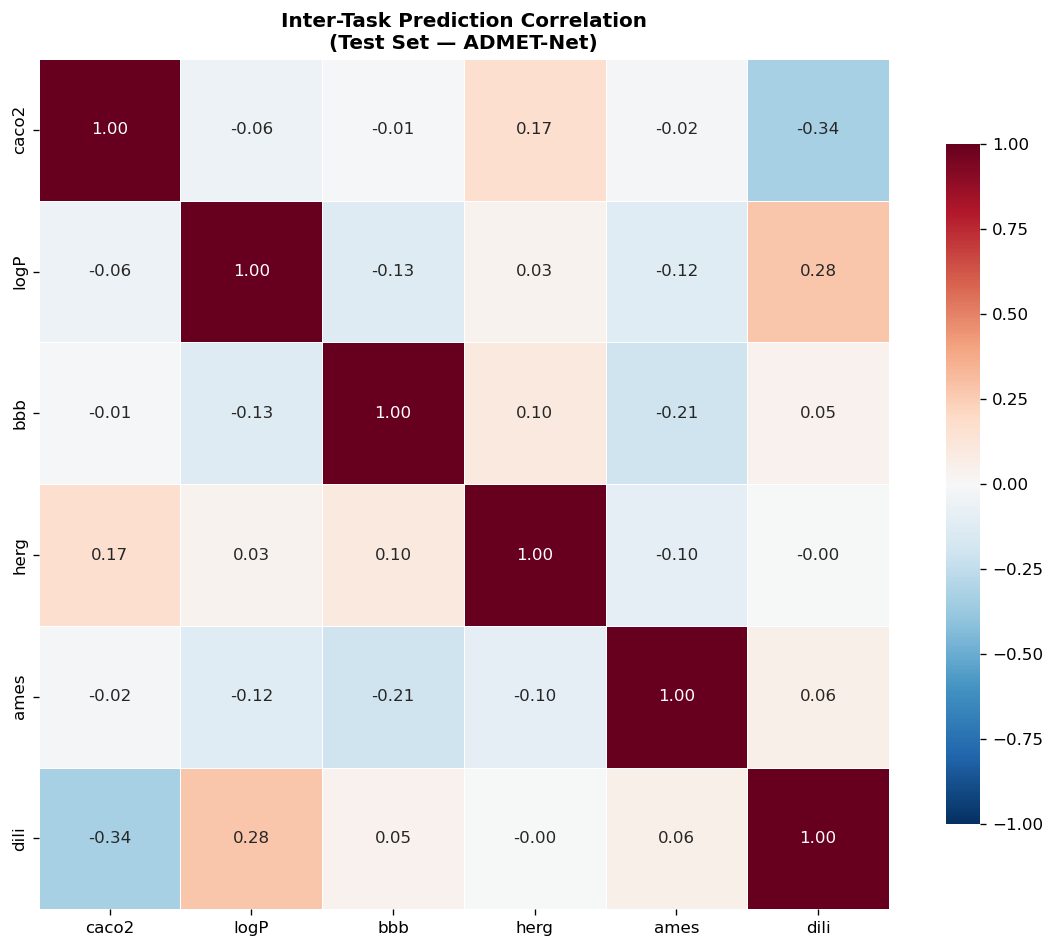

Correlation heatmap saved!


In [7]:
tasks_with_data = [t for t in TASK_NAMES if len(all_preds_raw[t]) > 10]

if len(tasks_with_data) > 1:
    min_len = min(len(all_preds_raw[t]) for t in tasks_with_data)

    pred_matrix = pd.DataFrame({
        task: (
            sigmoid(np.array(all_preds_raw[task][:min_len]))
            if TASK_CONFIG[task][0] == 'classification'
            else np.array(all_preds_raw[task][:min_len])
        )
        for task in tasks_with_data
    })

    corr = pred_matrix.corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        corr, annot=True, fmt='.2f', cmap='RdBu_r',
        center=0, square=True, linewidths=0.5, ax=ax,
        vmin=-1, vmax=1, cbar_kws={'shrink': 0.8}
    )
    ax.set_title(
        'Inter-Task Prediction Correlation\n(Test Set — ADMET-Net)',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('results/figures/task_correlation_heatmap.png', bbox_inches='tight')
    plt.show()
    print('Correlation heatmap saved!')
else:
    print('Not enough tasks with data for correlation heatmap.')

## 7. SHAP Feature Importance

FP tensor shape: torch.Size([200, 2048])


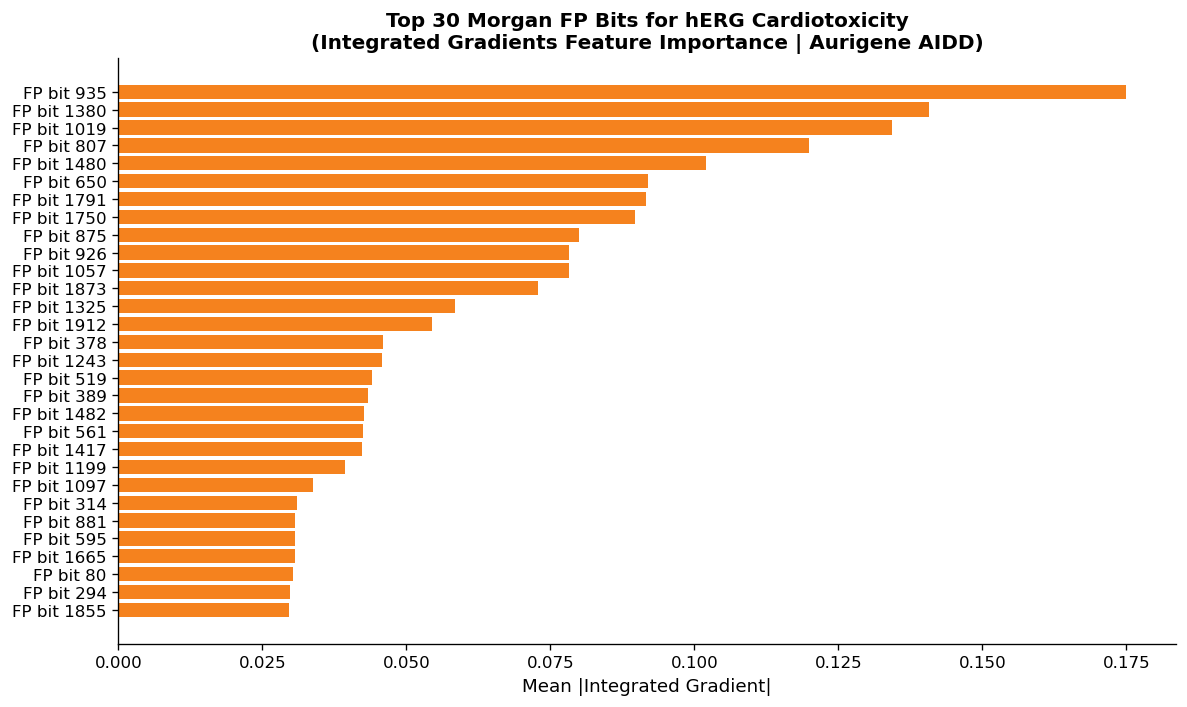

Feature importance plot saved!


In [8]:
# Feature Importance via Integrated Gradients
# (More compatible than SHAP DeepLift for GNN architectures)

class FPOnlyModel(torch.nn.Module):
    def __init__(self, full_model, task):
        super().__init__()
        self.fp_enc = full_model.fp_encoder
        self.fusion = full_model.fusion
        self.head   = full_model.heads[task]

    def forward(self, fp):
        fp_emb    = self.fp_enc(fp)
        graph_dim = self.fusion.net[0].in_features - fp_emb.shape[1]
        graph_emb = torch.zeros(fp.shape[0], graph_dim, device=fp.device)
        fused     = self.fusion(torch.cat([graph_emb, fp_emb], dim=-1))
        return self.head(fused)

# Collect fingerprints
test_fps_list = []
with torch.no_grad():
    for batch in test_dl:
        test_fps_list.append(batch.fp.squeeze(1))
        if len(test_fps_list) * cfg['training']['batch_size'] > 200:
            break
test_fps_tensor = torch.cat(test_fps_list, dim=0)[:200]
print(f'FP tensor shape: {test_fps_tensor.shape}')

shap_task = 'herg'
fp_model  = FPOnlyModel(model, shap_task)
fp_model.eval()

# Integrated Gradients
baseline   = torch.zeros_like(test_fps_tensor[:1])
query      = test_fps_tensor[:100]
n_steps    = 20
integrated = torch.zeros_like(query)

for alpha in np.linspace(0, 1, n_steps):
    interp = baseline + alpha * (query - baseline)
    interp = interp.requires_grad_(True)
    out    = fp_model(interp).sum()
    out.backward()
    integrated += interp.grad.detach()

integrated = integrated / n_steps
importance = (integrated * (query - baseline)).abs()
mean_importance = importance.mean(dim=0).numpy()

# Plot top 30 bits
top30_idx = np.argsort(mean_importance)[::-1][:30]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    [f'FP bit {i}' for i in top30_idx[::-1]],
    mean_importance[top30_idx][::-1],
    color=AURIGENE_ORANGE
)
ax.set_xlabel('Mean |Integrated Gradient|', fontsize=11)
ax.set_title(
    'Top 30 Morgan FP Bits for hERG Cardiotoxicity\n'
    '(Integrated Gradients Feature Importance | Aurigene AIDD)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('results/figures/shap_herg_top30.png', bbox_inches='tight')
plt.show()
print('Feature importance plot saved!')

## 8. Final Summary

In [10]:
print('=' * 60)
print('  ADMET-Net Final Evaluation Summary')
print('  Aurigene Pharmaceutical Services | AIDD Group')
print('=' * 60)

results_df = pd.read_csv('results/metrics_summary.csv')
print(results_df.to_string(index=False))

print('\nFigures generated:')
for f in os.listdir('results/figures'):
    print(f'  results/figures/{f}')


  ADMET-Net Final Evaluation Summary
  Aurigene Pharmaceutical Services | AIDD Group
           Task           Type  N_test Metric  Score
          caco2     regression      63   RMSE 0.5800
bioavailability classification       0    AUC    NaN
           logP     regression      83   RMSE 1.5739
            bbb classification     210    AUC 0.7099
         cyp3a4 classification       0    AUC    NaN
         cyp2c9 classification       0    AUC    NaN
         cyp2d6 classification       0    AUC    NaN
      half_life     regression       0   RMSE    NaN
      clearance     regression       0   RMSE    NaN
           herg classification    1545    AUC 0.8312
           ames classification     566    AUC 0.9367
           dili classification      63    AUC 0.8377

Figures generated:
  results/figures/confusion_matrices.png
  results/figures/output.png
  results/figures/output1.png
  results/figures/output2.png
  results/figures/output3.png
  results/figures/output4.png
  results/figure